# Multi-species UCE inference — mouse OPC dataset

Loads `KuanP/uce-multispecies-2025-11-08` and runs cell-embedding extraction on a mouse cortex OPC dataset (`631a4f61-918e-4229-9daf-94ef500a4f25.h5ad`, 38,807 cells × 51,727 genes). Plots a UMAP coloured by the dataset's curated OPC sub-state labels (`final_identity`, `new_identity`) plus age (`new_age`).

Two mouse-specific gotchas the notebook handles:

1. **`var_names` are Ensembl IDs** (`ENSMUSG...`); proper symbols live in `var['feature_name']`. We pass `gene_symbol_column='feature_name'` to pick them up.
2. **Case mismatch**: vocab[mouse] keys are uppercase HGNC-style (`XKR4`, `SOX17`), but MGI symbols use sentence case (`Xkr4`, `Sox17`). Direct match gives ~95/51K; with `case_insensitive=True` it jumps to ~19.7K/51K (≈92% of vocab covered).

In [10]:
H5AD_PATH      = "/data/kuan/brain_benchmark_data/631a4f61-918e-4229-9daf-94ef500a4f25.h5ad"
HF_REPO        = "KuanP/uce-multispecies-2025-11-08"
SPECIES        = "mouse"            # vocab JSON key for mouse
MAX_CELLS      = 5000                # set to None for full dataset (~38.8k cells)
BATCH_SIZE     = 16
NUM_WORKERS    = 4
SUBSAMPLE_SEED = 0

In [ ]:
import numpy as np
import scanpy as sc
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from huggingface_hub import hf_hub_download

from uce_brain.model import UCEForExpressionPrediction
from uce_brain.data import H5ADDataset, UCEDataCollator, load_gene_mapping, read_h5ad_subsampled

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

In [12]:
model = UCEForExpressionPrediction.from_pretrained(HF_REPO).eval().to(device)
vocab_path = hf_hub_download(HF_REPO, 'gene_mapping.json')
gene_mapping = load_gene_mapping(vocab_path)
print('vocab species:', sorted(gene_mapping.keys()))
print(f'vocab_size={model.config.vocab_size}  d_model={model.config.d_model}  layers={model.config.num_layers}')

2026-05-26 12:54:12,415 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/KuanP/uce-multispecies-2025-11-08/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-26 12:54:12,428 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/KuanP/uce-multispecies-2025-11-08/45d49578730c55e879f47a932ff3b3a4080b6713/config.json "HTTP/1.1 200 OK"
2026-05-26 12:54:12,575 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/KuanP/uce-multispecies-2025-11-08/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/118 [00:00<?, ?it/s]

2026-05-26 12:54:19,242 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/KuanP/uce-multispecies-2025-11-08/resolve/main/gene_mapping.json "HTTP/1.1 302 Found"
2026-05-26 12:54:19,249 - uce_brain.data.dataset - INFO - Loading gene mapping from /home/kuan/.cache/huggingface/hub/models--KuanP--uce-multispecies-2025-11-08/snapshots/45d49578730c55e879f47a932ff3b3a4080b6713/gene_mapping.json
2026-05-26 12:54:19,389 - uce_brain.data.dataset - INFO - Top-level species keys: ['callithrix_jacchus', 'frog', 'human', 'macaca_fascicularis', 'macaca_mulatta', 'mouse', 'mouse_lemur', 'pan_troglodytes', 'pig', 'zebrafish']


vocab species: ['callithrix_jacchus', 'frog', 'human', 'macaca_fascicularis', 'macaca_mulatta', 'mouse', 'mouse_lemur', 'pan_troglodytes', 'pig', 'zebrafish']
vocab_size=178331  d_model=512  layers=8


In [ ]:
# Sparse-aware sub-row read: pulls only the cells we need
# (~10x faster than sc.read_h5ad() for small subsamples; about 6x faster on the 30 GB marmoset file at 5000 cells).
if MAX_CELLS is None:
    adata = sc.read_h5ad(H5AD_PATH)   # full file; ~4 min for marmoset
else:
    adata = read_h5ad_subsampled(H5AD_PATH, n_cells=MAX_CELLS, seed=SUBSAMPLE_SEED)
print('shape:', adata.shape, '  X type:', type(adata.X).__name__)
print(
    'obs label columns:',
    [c for c in ('Neighborhood','Class','Subclass','Group','cell_type_ontology_term',
                 'final_identity','new_identity','new_age','batch','cell_type','tissue')
     if c in adata.obs.columns],
)


In [14]:
dataset = H5ADDataset(
    adata,
    gene_mapping=gene_mapping,
    species=SPECIES,
    gene_symbol_column='feature_name',  # var_names are ENSMUSG IDs
    case_insensitive=True,              # MGI sentence-case vs vocab uppercase
    mask_prop=0.0,
)
collator = UCEDataCollator()
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collator,
    pin_memory=True,
)
print(f'dataset size: {len(dataset)} cells, {len(dataloader)} batches of {BATCH_SIZE}')
print(f'gene overlap: {len(dataset.aligned_gene_names)} / {adata.n_vars} h5ad genes mapped to vocab[{SPECIES}]')

2026-05-26 12:59:14,640 - uce_brain.data.dataset - INFO - Loading AnnData object with shape (5000, 51727)
2026-05-26 12:59:14,641 - uce_brain.data.dataset - INFO - Loaded 5000 cells with 51727 genes
2026-05-26 12:59:14,643 - uce_brain.data.dataset - INFO - var_names look like Ensembl IDs (e.g. 'ENSMUSG00000000001'); looking for gene symbols...
2026-05-26 12:59:14,649 - uce_brain.data.dataset - INFO - Using gene symbols from column 'feature_name'
2026-05-26 12:59:14,654 - uce_brain.data.dataset - INFO - Aligning h5ad genes to gene mapping...
2026-05-26 12:59:14,661 - uce_brain.data.dataset - INFO -   Built uppercase lookup for 21522 vocab entries
2026-05-26 12:59:14,671 - uce_brain.data.dataset - INFO -   H5AD genes: 51727
2026-05-26 12:59:14,671 - uce_brain.data.dataset - INFO -   Gene mapping vocabulary: 21522
2026-05-26 12:59:14,672 - uce_brain.data.dataset - INFO -   Genes in common: 19718 (case-insensitive)


dataset size: 5000 cells, 313 batches of 16
gene overlap: 19718 / 51727 h5ad genes mapped to vocab[mouse]


In [15]:
embeddings = np.empty((len(dataset), model.config.output_embedding_dim), dtype=np.float32)
ptr = 0
with torch.inference_mode():
    for batch in tqdm(dataloader, desc='extracting embeddings'):
        out = model.extract_cell_embeddings(
            input_ids=batch['input_ids'].to(device, non_blocking=True),
            attention_mask=batch['attention_mask'].to(device, non_blocking=True),
        )
        emb = out.cell_embedding.float().cpu().numpy()
        embeddings[ptr:ptr+emb.shape[0]] = emb
        ptr += emb.shape[0]
print('embeddings:', embeddings.shape, 'finite:', np.isfinite(embeddings).all())

extracting embeddings:   0%|          | 0/313 [00:00<?, ?it/s]

embeddings: (5000, 512) finite: True


In [16]:
adata.obsm['X_uce'] = embeddings
sc.pp.neighbors(adata, use_rep='X_uce', n_neighbors=15)
sc.tl.umap(adata, min_dist=0.3)

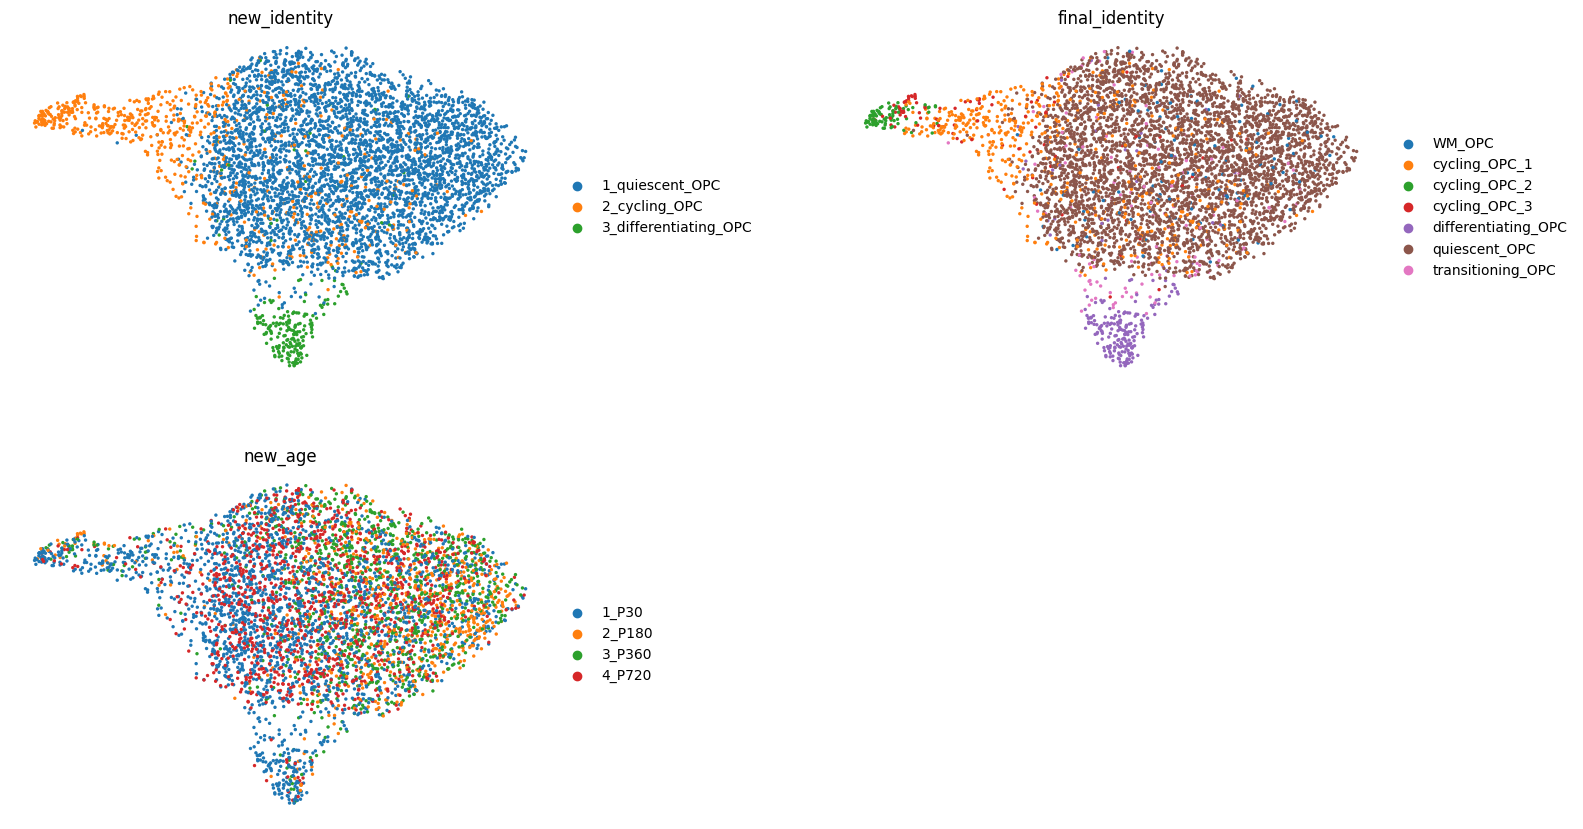

In [17]:
import matplotlib.pyplot as plt
color_keys = [c for c in ('new_identity', 'final_identity', 'new_age') if c in adata.obs.columns]
if color_keys:
    sc.pl.umap(adata, color=color_keys, ncols=2, frameon=False, wspace=0.4)
else:
    sc.pl.umap(adata, frameon=False)
    print('no curated label columns found; plotted unlabeled UMAP only')